In [ ]:
import matplotlib.pyplot as plt

# Daten für TensorRT-Modelle
models = [
    "BEVDetNet FP32 TRT", "BEVDetNet FP16 TRT", "BEVDetNet INT8 TRT",
    "Our FP32 TRT", "Our FP16 TRT", "Our INT8 TRT"
]
latency = [6, 4, 2.1, 2.9, 1.7, 1.5]
performance = [87.51, 86.44, 84.20, 76.52, 76.50, 67.32]
colors = ['blue', 'blue', 'blue', 'red', 'red', 'red']
sizes = [59, 39, 22, 49, 25, 16]  # model size in MB

# Diagramm mit größerer Figur erstellen
plt.figure(figsize=(12, 7))
scatter = plt.scatter(latency, performance, c=colors, s=[s*10 for s in sizes], alpha=0.7)

# Achsenbereiche manuell festlegen
plt.xlim(0.8, 7.5)  # Latenz-Achse von 0.8ms bis 7.5ms
plt.ylim(60, 92)    # Performance-Achse von 60% bis 92%

# Beschriftungen mit Pfeilen
for i, model in enumerate(models):
    if i < 3:  # BEVDetNet Modelle
        offset = (15, 15)
    elif i == 3:  # Unser FP32 TRT - weiter nach rechts
        offset = (30, -20)  # Größerer x-Offset für mehr Abstand nach rechts
    else:  # Unser FP16 TRT und INT8 TRT - unverändert
        offset = (15, -20)
    
    plt.annotate(f"{model}\n{performance[i]}% | {latency[i]}ms | {sizes[i]}MB", 
                (latency[i], performance[i]), 
                xytext=offset,
                textcoords="offset points",
                ha='left',
                va='bottom' if i < 3 else 'top',
                fontsize=7,
                arrowprops=dict(arrowstyle="->", connectionstyle="arc3", color='gray'),
                bbox=dict(boxstyle='round,pad=0.5', fc='white', alpha=0.8))

plt.xlabel('Latency (ms)', fontsize=12)
plt.ylabel('Average Precision (%)', fontsize=12)
plt.title('Comparison of TensorRT models: latency vs. average precision', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)

# Legende erstellen
blue_patch = plt.Line2D([0], [0], marker='o', color='w', label='BEVDetNet TRT', 
                       markerfacecolor='blue', markersize=8)
red_patch = plt.Line2D([0], [0], marker='o', color='w', label='Our model TRT', 
                      markerfacecolor='red', markersize=8)

# Größen-Legende
size_legends = []
for size, label in zip([20, 40, 60], ['Small', 'Medium', 'Large']):
    size_legends.append(plt.scatter([], [], c='gray', alpha=0.5, s=size*5, label=label))

# Legende weiter rechts platzieren (bbox_to_anchor x-Wert erhöht)
legend = plt.legend(handles=[blue_patch, red_patch] + size_legends,
                   title='Legend', loc='upper left', 
                   bbox_to_anchor=(1.18, 1),  # x-Position von 1.02 auf 1.18 erhöht
                   borderaxespad=0.,
                   handletextpad=1.5,
                   labelspacing=1.2)

# Rahmen um die Legende
legend.get_frame().set_alpha(0.8)
legend.get_frame().set_edgecolor('black')

# Anpassung des Layouts für mehr Platz rechts
plt.tight_layout(rect=[0, 0, 0.82, 1])  # rect Parameter angepasst

#plt.savefig('tensorrt_comparison.svg', format='svg', dpi=300, bbox_inches='tight')
plt.show()

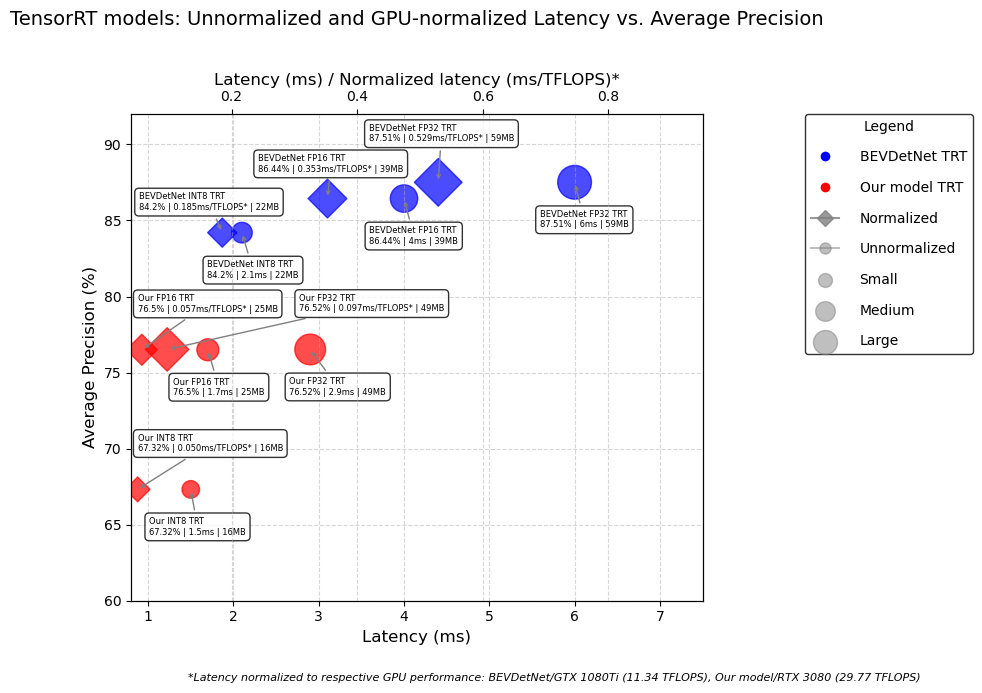

Standardized latency (ms/TFLOPS):
BEVDetNet FP32 TRT: 6ms / 11.34 TFLOPS = 0.529 ms/TFLOPS
BEVDetNet FP16 TRT: 4ms / 11.34 TFLOPS = 0.353 ms/TFLOPS
BEVDetNet INT8 TRT: 2.1ms / 11.34 TFLOPS = 0.185 ms/TFLOPS
Our FP32 TRT: 2.9ms / 29.77 TFLOPS = 0.097 ms/TFLOPS
Our FP16 TRT: 1.7ms / 29.77 TFLOPS = 0.057 ms/TFLOPS
Our INT8 TRT: 1.5ms / 29.77 TFLOPS = 0.050 ms/TFLOPS


In [2]:
import matplotlib.pyplot as plt

# Data for TensorRT models
models = [
    "BEVDetNet FP32 TRT", "BEVDetNet FP16 TRT", "BEVDetNet INT8 TRT",
    "Our FP32 TRT", "Our FP16 TRT", "Our INT8 TRT"
]
latency_original = [6, 4, 2.1, 2.9, 1.7, 1.5]  # BEVDETNET latency in ms
performance = [87.51, 86.44, 84.20, 76.52, 76.50, 67.32]
colors = ['blue', 'blue', 'blue', 'red', 'red', 'red']
sizes = [59, 39, 22, 49, 25, 16]  # model size in MB

# GPU FLOPS (in TFLOPS)
bevdetnet_flops = 11.34  # NVIDIA GeForce GTX 1080 Ti (11GB)
rtx3080_flops = 29.77   # NVIDIA RTX 3080 (10GB)

# Normalization of latency based on FLOPS (latency per TFLOPS)
# Formula: normalised_latency = original_latency / gpu_flops
latency_normalized = []
for i, latency in enumerate(latency_original):
    if i < 3:  # BEVDetNet models (on GTX 1080Ti)
        # Standardization: Latency per TFLOPS
        normalized = latency / bevdetnet_flops
    else:  # Our model (on RTX 3080)
        normalized = latency / rtx3080_flops
    latency_normalized.append(normalized)

# Create a diagram with a larger figure
fig, ax1 = plt.subplots(figsize=(12, 7))

# Unnormalized latency (ms) on ax1
scatter_unnorm = ax1.scatter(latency_original, performance, c=colors, s=[s*10 for s in sizes], alpha=0.7, marker='o', label='Unnormalized latency (ms)')
ax1.set_xlabel('Latency (ms)', fontsize=12)
ax1.set_xlim(0.8, 7.5)

# Second x-axis for standardized values
ax2 = ax1.twiny()
scatter_norm = ax2.scatter(latency_normalized, performance, c=colors, s=[s*10 for s in sizes], alpha=0.7, marker='D', label='Normalized latency (ms/TFLOPS)')
ax2.set_xlabel('Normalized latency (ms/TFLOPS)*', fontsize=12)
ax2.set_xlim(0.04, 0.95)

ax1.set_ylabel('Average Precision (%)', fontsize=12)
ax1.set_ylim(60, 92)
ax1.grid(True, linestyle='--', alpha=0.5)

# Labels with arrows
for i, model in enumerate(models):
    if i < 3:
        offset = ()
        if i == 0:  # FP32 
            offset = (-25, -20)
        elif i == 1:  # FP16
            offset = (-25, -20)
        else:  # INT8 
            offset = (-25, -20)
    elif i == 3:  # Our FP32 TRT 
        offset = (-15, -20)
    elif i == 4:  # Our FP16 TRT
        offset = (-25, -20)
    else:  # Our INT8 TRT
        offset = (-30, -20)
    
    ax1.annotate(
        f"{model}\n{performance[i]}% | {latency_original[i]}ms | {sizes[i]}MB",
        (latency_original[i], performance[i]),
        xytext=offset,
        textcoords="offset points",
        ha='left',
        va='top',
        fontsize=6,
        arrowprops=dict(arrowstyle="->", connectionstyle="arc3", color='gray'),
        bbox=dict(boxstyle='round,pad=0.5', fc='white', alpha=0.8)
    )
    
# Labels with arrows for GPU-normalized
for i, model in enumerate(models):
    if i < 3:  # BEVDetNet models
        if i == 0:  # FP32 
            offset = (-50, 28)
        elif i == 1:  # FP16 
            offset = (-50, 18)
        else:  # INT8 
            offset = (-60, 15)
    elif i == 3:  # Our FP32 TRT
        offset = (95, 40)
    elif i == 4:  # Our FP16 TRT
        offset = (-3, 40)
    else:  # INT8 TRT
        offset = (0, 40)
    
    ax2.annotate(f"{model}\n{performance[i]}% | {latency_normalized[i]:.3f}ms/TFLOPS* | {sizes[i]}MB", 
                (latency_normalized[i], performance[i]), 
                xytext=offset,
                textcoords="offset points",
                ha='left',
                va='bottom' if i < 3 else 'top',
                fontsize=6,
                arrowprops=dict(arrowstyle="->", connectionstyle="arc3", color='gray'),
                bbox=dict(boxstyle='round,pad=0.5', fc='white', alpha=0.8))
    
plt.xlabel('\nLatency (ms) / Normalized latency (ms/TFLOPS)*', fontsize=12)
plt.ylabel('Average Precision (%)', fontsize=12)
plt.title('TensorRT models: Unnormalized and GPU-normalized Latency vs. Average Precision\n', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)

# Create legend
blue_patch = plt.Line2D([0], [0], marker='o', color='w', label='BEVDetNet TRT', 
                       markerfacecolor='blue', markersize=8)
red_patch = plt.Line2D([0], [0], marker='o', color='w', label='Our model TRT', 
                      markerfacecolor='red', markersize=8)
norm_patch = plt.Line2D([0], [0], marker='D', color='gray', label='Normalized', 
                        markersize=8, alpha=0.8)
unnorm_patch = plt.Line2D([0], [0], marker='o', color='gray', label='Unnormalized',
                        markersize=8, alpha=0.5)
size_legends = [plt.scatter([], [], c='gray', alpha=0.5, s=size*5, label=label) for size, label in zip([20, 40, 60], ['Small', 'Medium', 'Large'])]

# Size legend
size_legends = []
for size, label in zip([20, 40, 60], ['Small', 'Medium', 'Large']):
    size_legends.append(plt.scatter([], [], c='gray', alpha=0.5, s=size*5, label=label))

# Place legend further to the right
legend = plt.legend(handles=[blue_patch, red_patch, norm_patch, unnorm_patch] + size_legends,
                   title='Legend', loc='upper left', 
                   bbox_to_anchor=(1.18, 1),
                   borderaxespad=0.,
                   handletextpad=1.5,
                   labelspacing=1.2)

# Frame around the legend
legend.get_frame().set_alpha(0.8)
legend.get_frame().set_edgecolor('black')

# Add footnote
plt.figtext(0.1, 0.02, '*Latency normalized to respective GPU performance: BEVDetNet/GTX 1080Ti (11.34 TFLOPS), Our model/RTX 3080 (29.77 TFLOPS)', 
            fontsize=8, style='italic')

# Adjusting the layout for more space on the right and bottom
plt.tight_layout(rect=[0, 0.05, 0.82, 1])
plt.savefig('tensorrt_comparison_final.svg', format='svg', dpi=300, bbox_inches='tight')
plt.show()


# Issuance of standardization factors for control purposes
print("Standardized latency (ms/TFLOPS):")
for i, model in enumerate(models):
    gpu_flops = bevdetnet_flops if i < 3 else rtx3080_flops
    print(f"{model}: {latency_original[i]}ms / {gpu_flops} TFLOPS = {latency_normalized[i]:.3f} ms/TFLOPS")